In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import celltypist
from celltypist import models
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase2_clustering"
RESULTS_DIR = PROJECT_DIR / "results" / "phase2_clustering"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [5]:
adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase2_clustered.h5ad")
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase2_clustered.h5ad")

adata1_full = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase1_qc_fullgenes.h5ad")
adata2_full = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase1_qc_fullgenes.h5ad")

print(adata1)
print(adata2)
print(adata1_full)
print(adata2_full)

AnnData object with n_obs × n_vars = 36607 × 2000
    obs: 'patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden_0.2', 'leiden_0.2_colors', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_0.6_colors', 'leiden_0.8', 'leiden_0.8_colors', 'leiden_1.0', 'leiden_1.0_colors', 'log1p', 'neighbors', 'patient_colors', 'pca', 'rank_genes_groups', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 82931 × 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype'

In [6]:
shared_cells1 = adata1.obs_names
shared_cells2 = adata2.obs_names

adata1_full = adata1_full[shared_cells1].copy()
adata2_full = adata2_full[shared_cells2].copy()

adata1_full.obsm["X_umap"] = adata1.obsm["X_umap"]
adata1_full.obs["leiden_0.6"] = adata1.obs["leiden_0.6"]

adata2_full.obsm["X_umap"] = adata2.obsm["X_umap"]
adata2_full.obs["leiden_0.6"] = adata2.obs["leiden_0.6"]

print("Done:", adata1_full.shape, adata2_full.shape)

Done: (36607, 14751) (82931, 27221)


In [2]:
import scanpy as sc
import numpy as np
from pathlib import Path

adata1 = sc.read_h5ad(r"C:\Users\annam\Dissertation 2026\Data\Processed\GSE114725_phase1_qc_harmony.h5ad")

# If scaling worked correctly, values should be roughly in range -10 to 10
# (max_value=10 was set in sc.pp.scale)
print("Min value:", adata1.X.min())
print("Max value:", adata1.X.max())
print("Mean:", adata1.X.mean())

Min value: -4.330071165733016
Max value: 10.0
Mean: -0.01064508197124782


In [3]:
import scanpy as sc
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"

adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase1_qc_harmony.h5ad")
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase1_qc_harmony.h5ad")

print(adata1)
print(adata2)

AnnData object with n_obs × n_vars = 36607 × 2000
    obs: 'patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'patient_colors', 'pca', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 82931 × 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cel

In [20]:
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase2_clustering"
RESULTS_DIR = PROJECT_DIR / "results" / "phase2_clustering"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase1_qc_harmony.h5ad")
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase1_qc_harmony.h5ad")

print(adata1)
print(adata2)

AnnData object with n_obs ?? n_vars = 36607 ?? 2000
    obs: 'patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'patient_colors', 'pca', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs ?? n_vars = 82931 ?? 2000
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n

In [21]:
print(adata1.obsm.keys())
print(adata2.obsm.keys())

KeysView(AxisArrays with keys: X_pca, X_pca_harmony, X_umap)
KeysView(AxisArrays with keys: X_pca, X_pca_harmony, X_umap)


In [22]:
def run_phase2_clustering(adata, dataset_name, n_pcs=30):
    print(f"Running Phase 2 clustering for {dataset_name}")

    sc.pp.neighbors(
        adata,
        use_rep="X_pca_harmony",
        n_neighbors=15,
        n_pcs=n_pcs
    )

    sc.tl.umap(adata)

    for resolution in [0.2, 0.4, 0.6, 0.8, 1.0]:
        key = f"leiden_{resolution}"
        sc.tl.leiden(
            adata,
            resolution=resolution,
            key_added=key
        )
        print(dataset_name, key, adata.obs[key].nunique(), "clusters")

    return adata

In [23]:
adata1 = run_phase2_clustering(adata1, "GSE114725")
adata2 = run_phase2_clustering(adata2, "GSE176078")

Running Phase 2 clustering for GSE114725


C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GSE114725 leiden_0.2 9 clusters
GSE114725 leiden_0.4 10 clusters
GSE114725 leiden_0.6 11 clusters
GSE114725 leiden_0.8 14 clusters
GSE114725 leiden_1.0 19 clusters
Running Phase 2 clustering for GSE176078
GSE176078 leiden_0.2 13 clusters
GSE176078 leiden_0.4 17 clusters
GSE176078 leiden_0.6 21 clusters
GSE176078 leiden_0.8 23 clusters
GSE176078 leiden_1.0 27 clusters


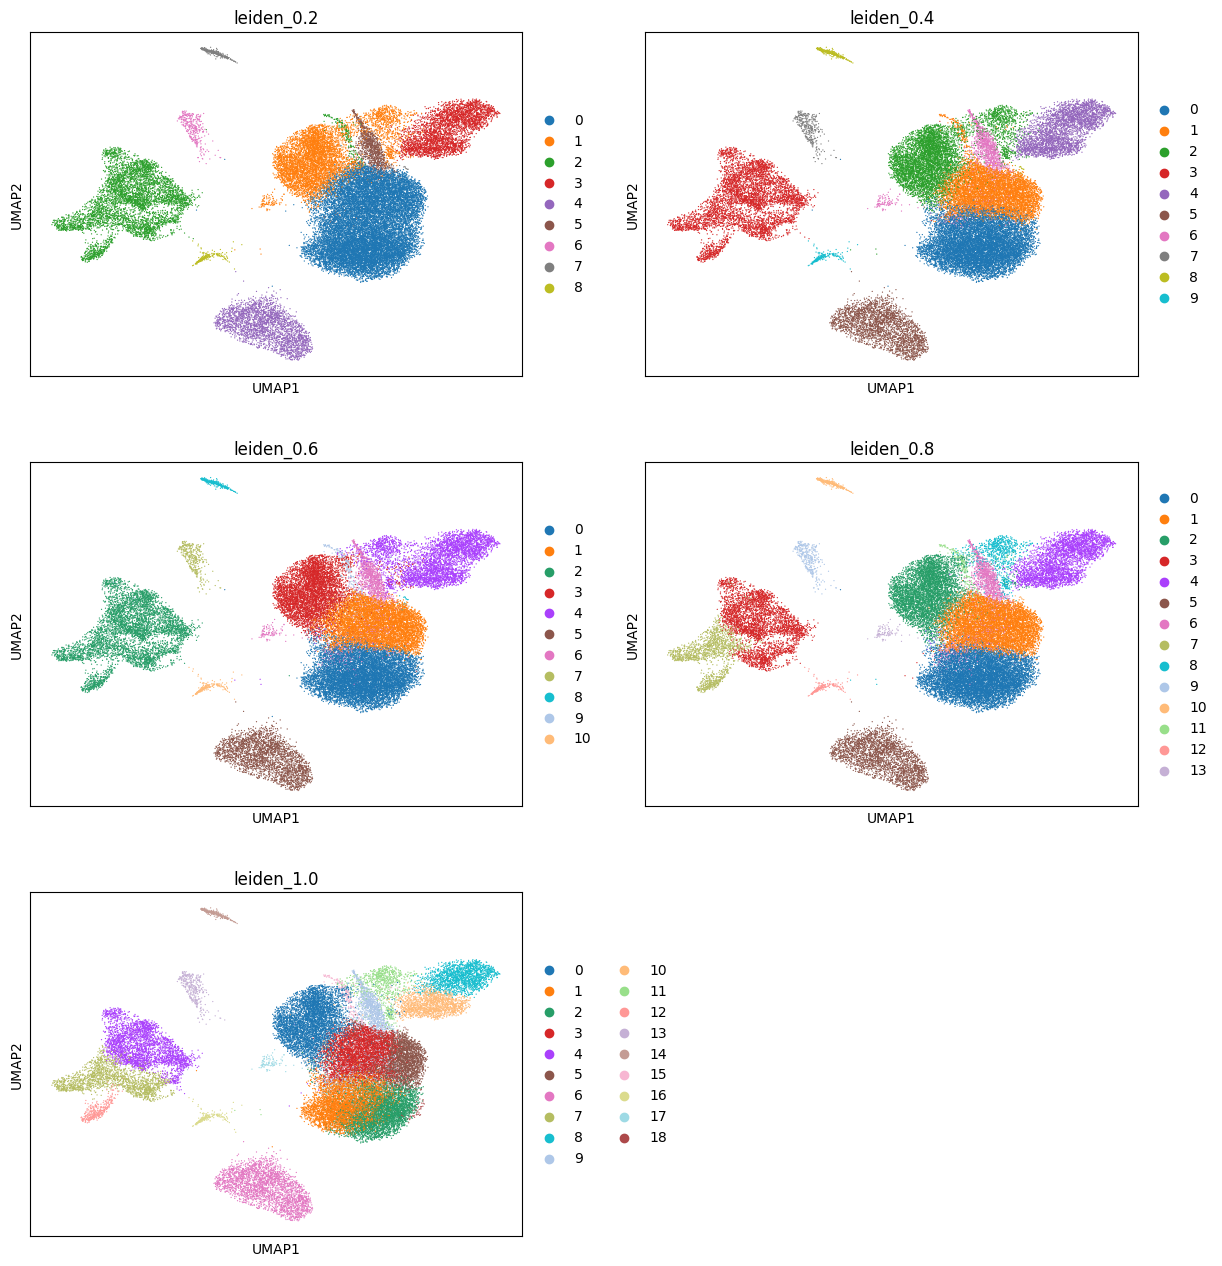

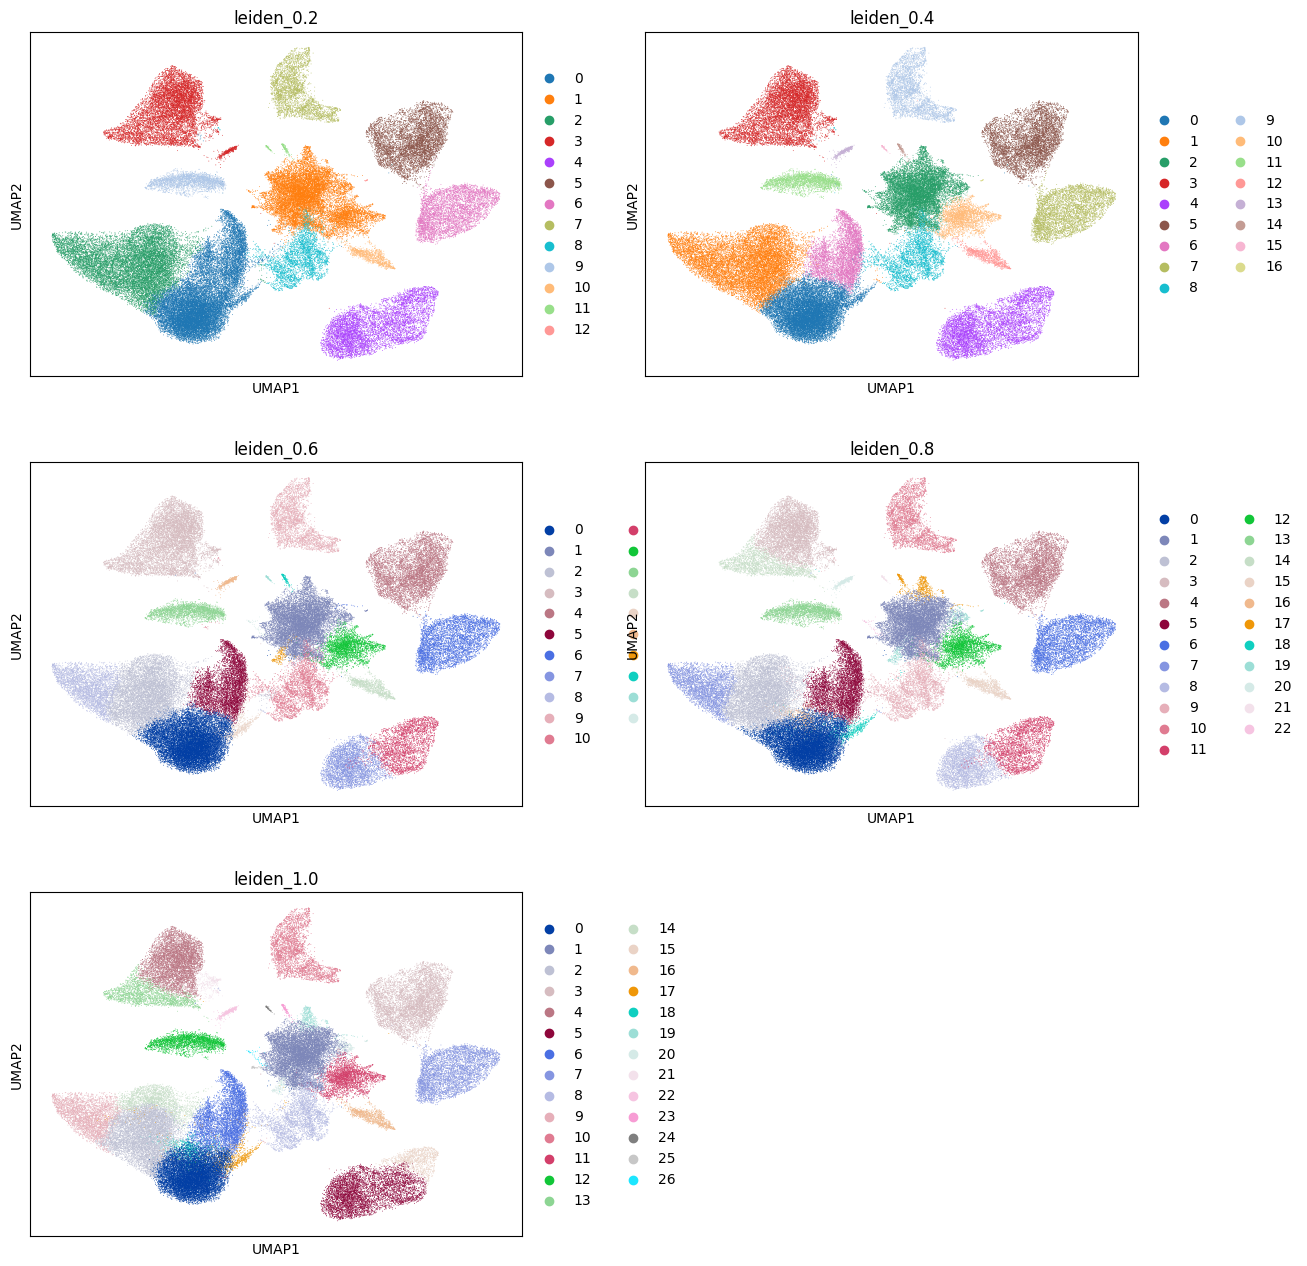

In [24]:
sc.pl.umap(
    adata1,
    color=["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"],
    ncols=2
)

sc.pl.umap(
    adata2,
    color=["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"],
    ncols=2
)

In [25]:
adata1.obs["leiden"] = adata1.obs["leiden_0.6"]
adata2.obs["leiden"] = adata2.obs["leiden_0.6"]

In [26]:
sc.tl.rank_genes_groups(
    adata1,
    groupby="leiden",
    method="wilcoxon"
)

sc.tl.rank_genes_groups(
    adata2,
    groupby="leiden",
    method="wilcoxon"
)

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is high

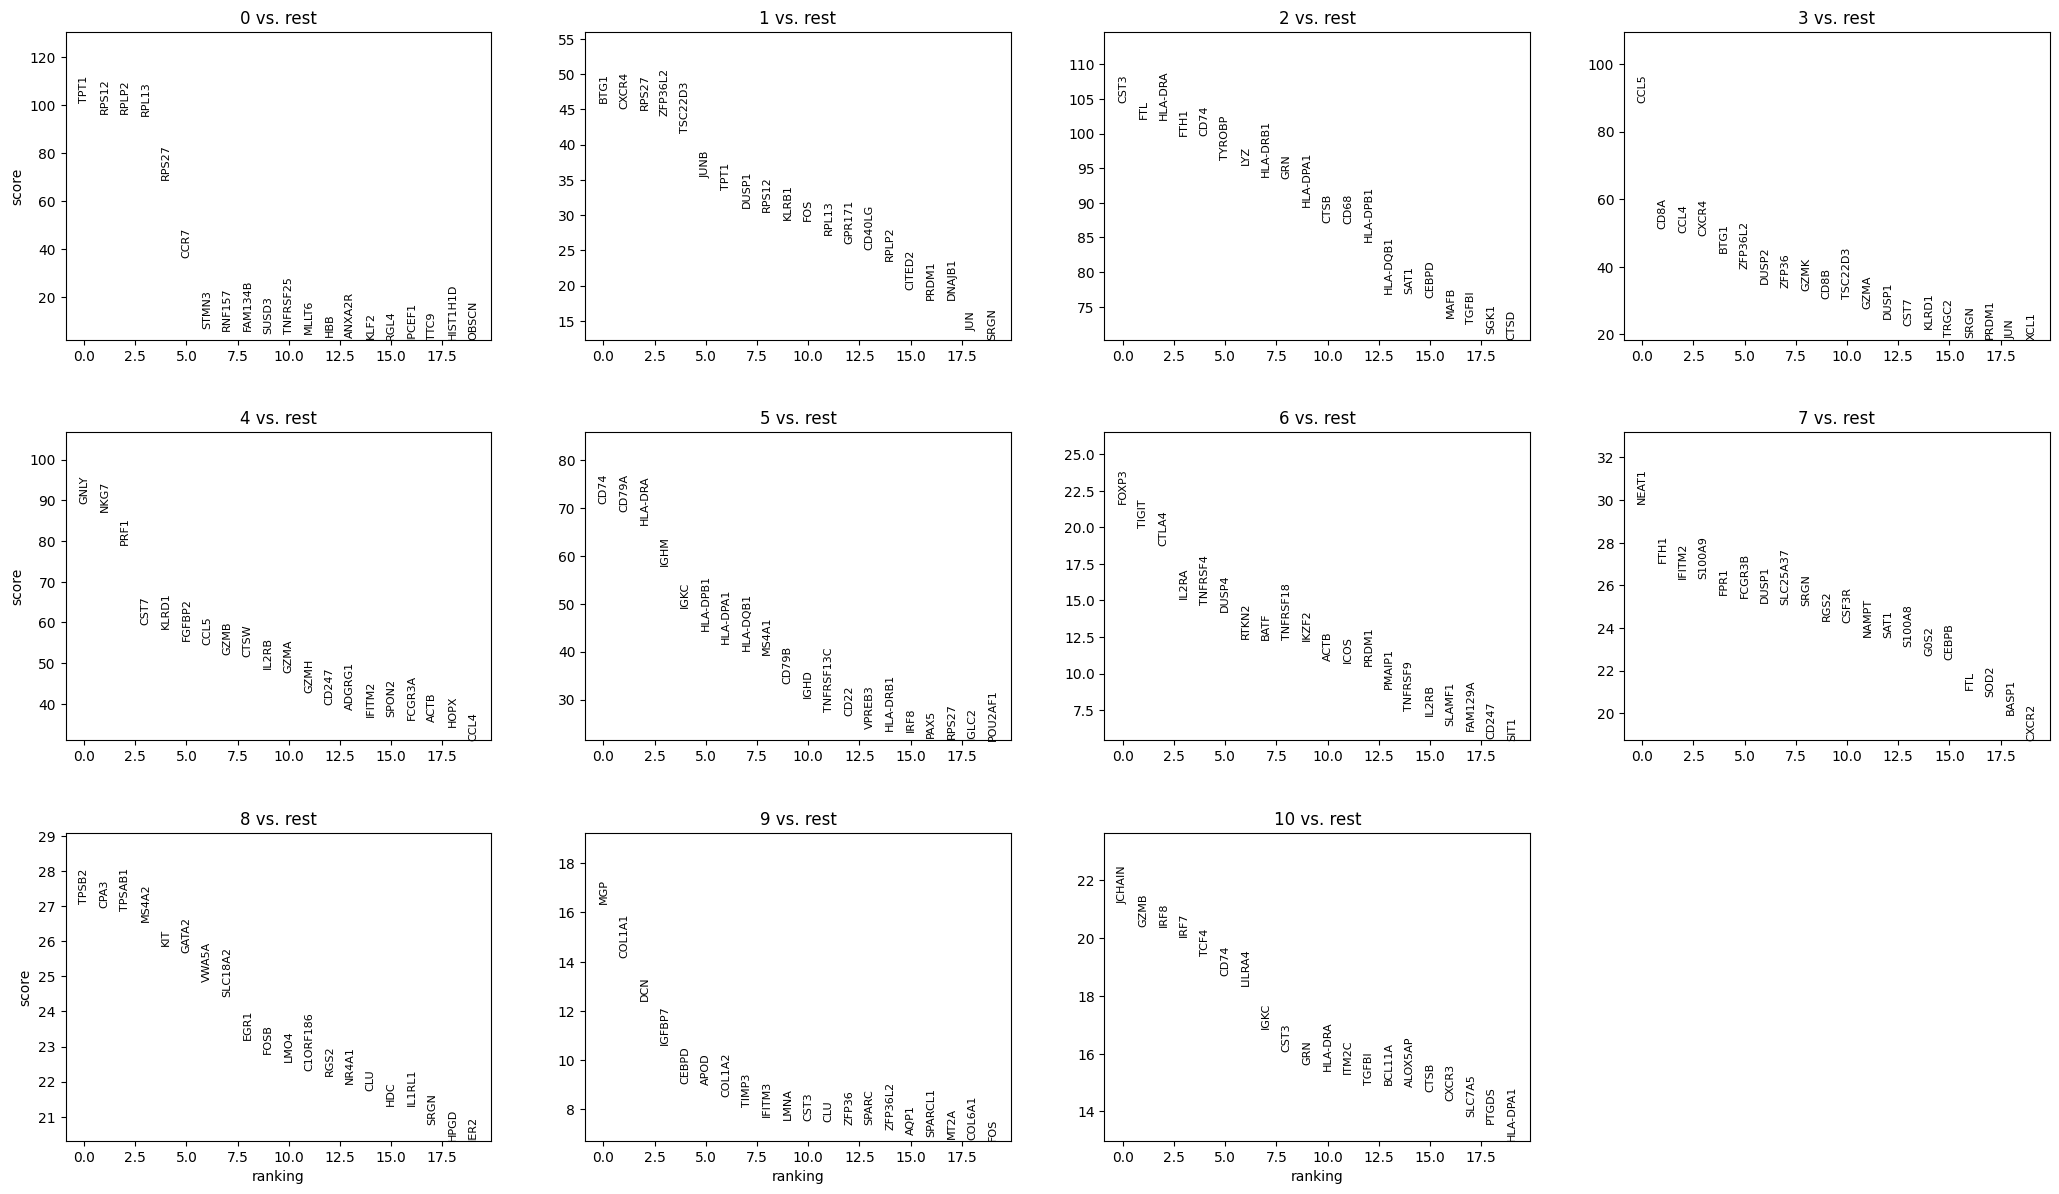

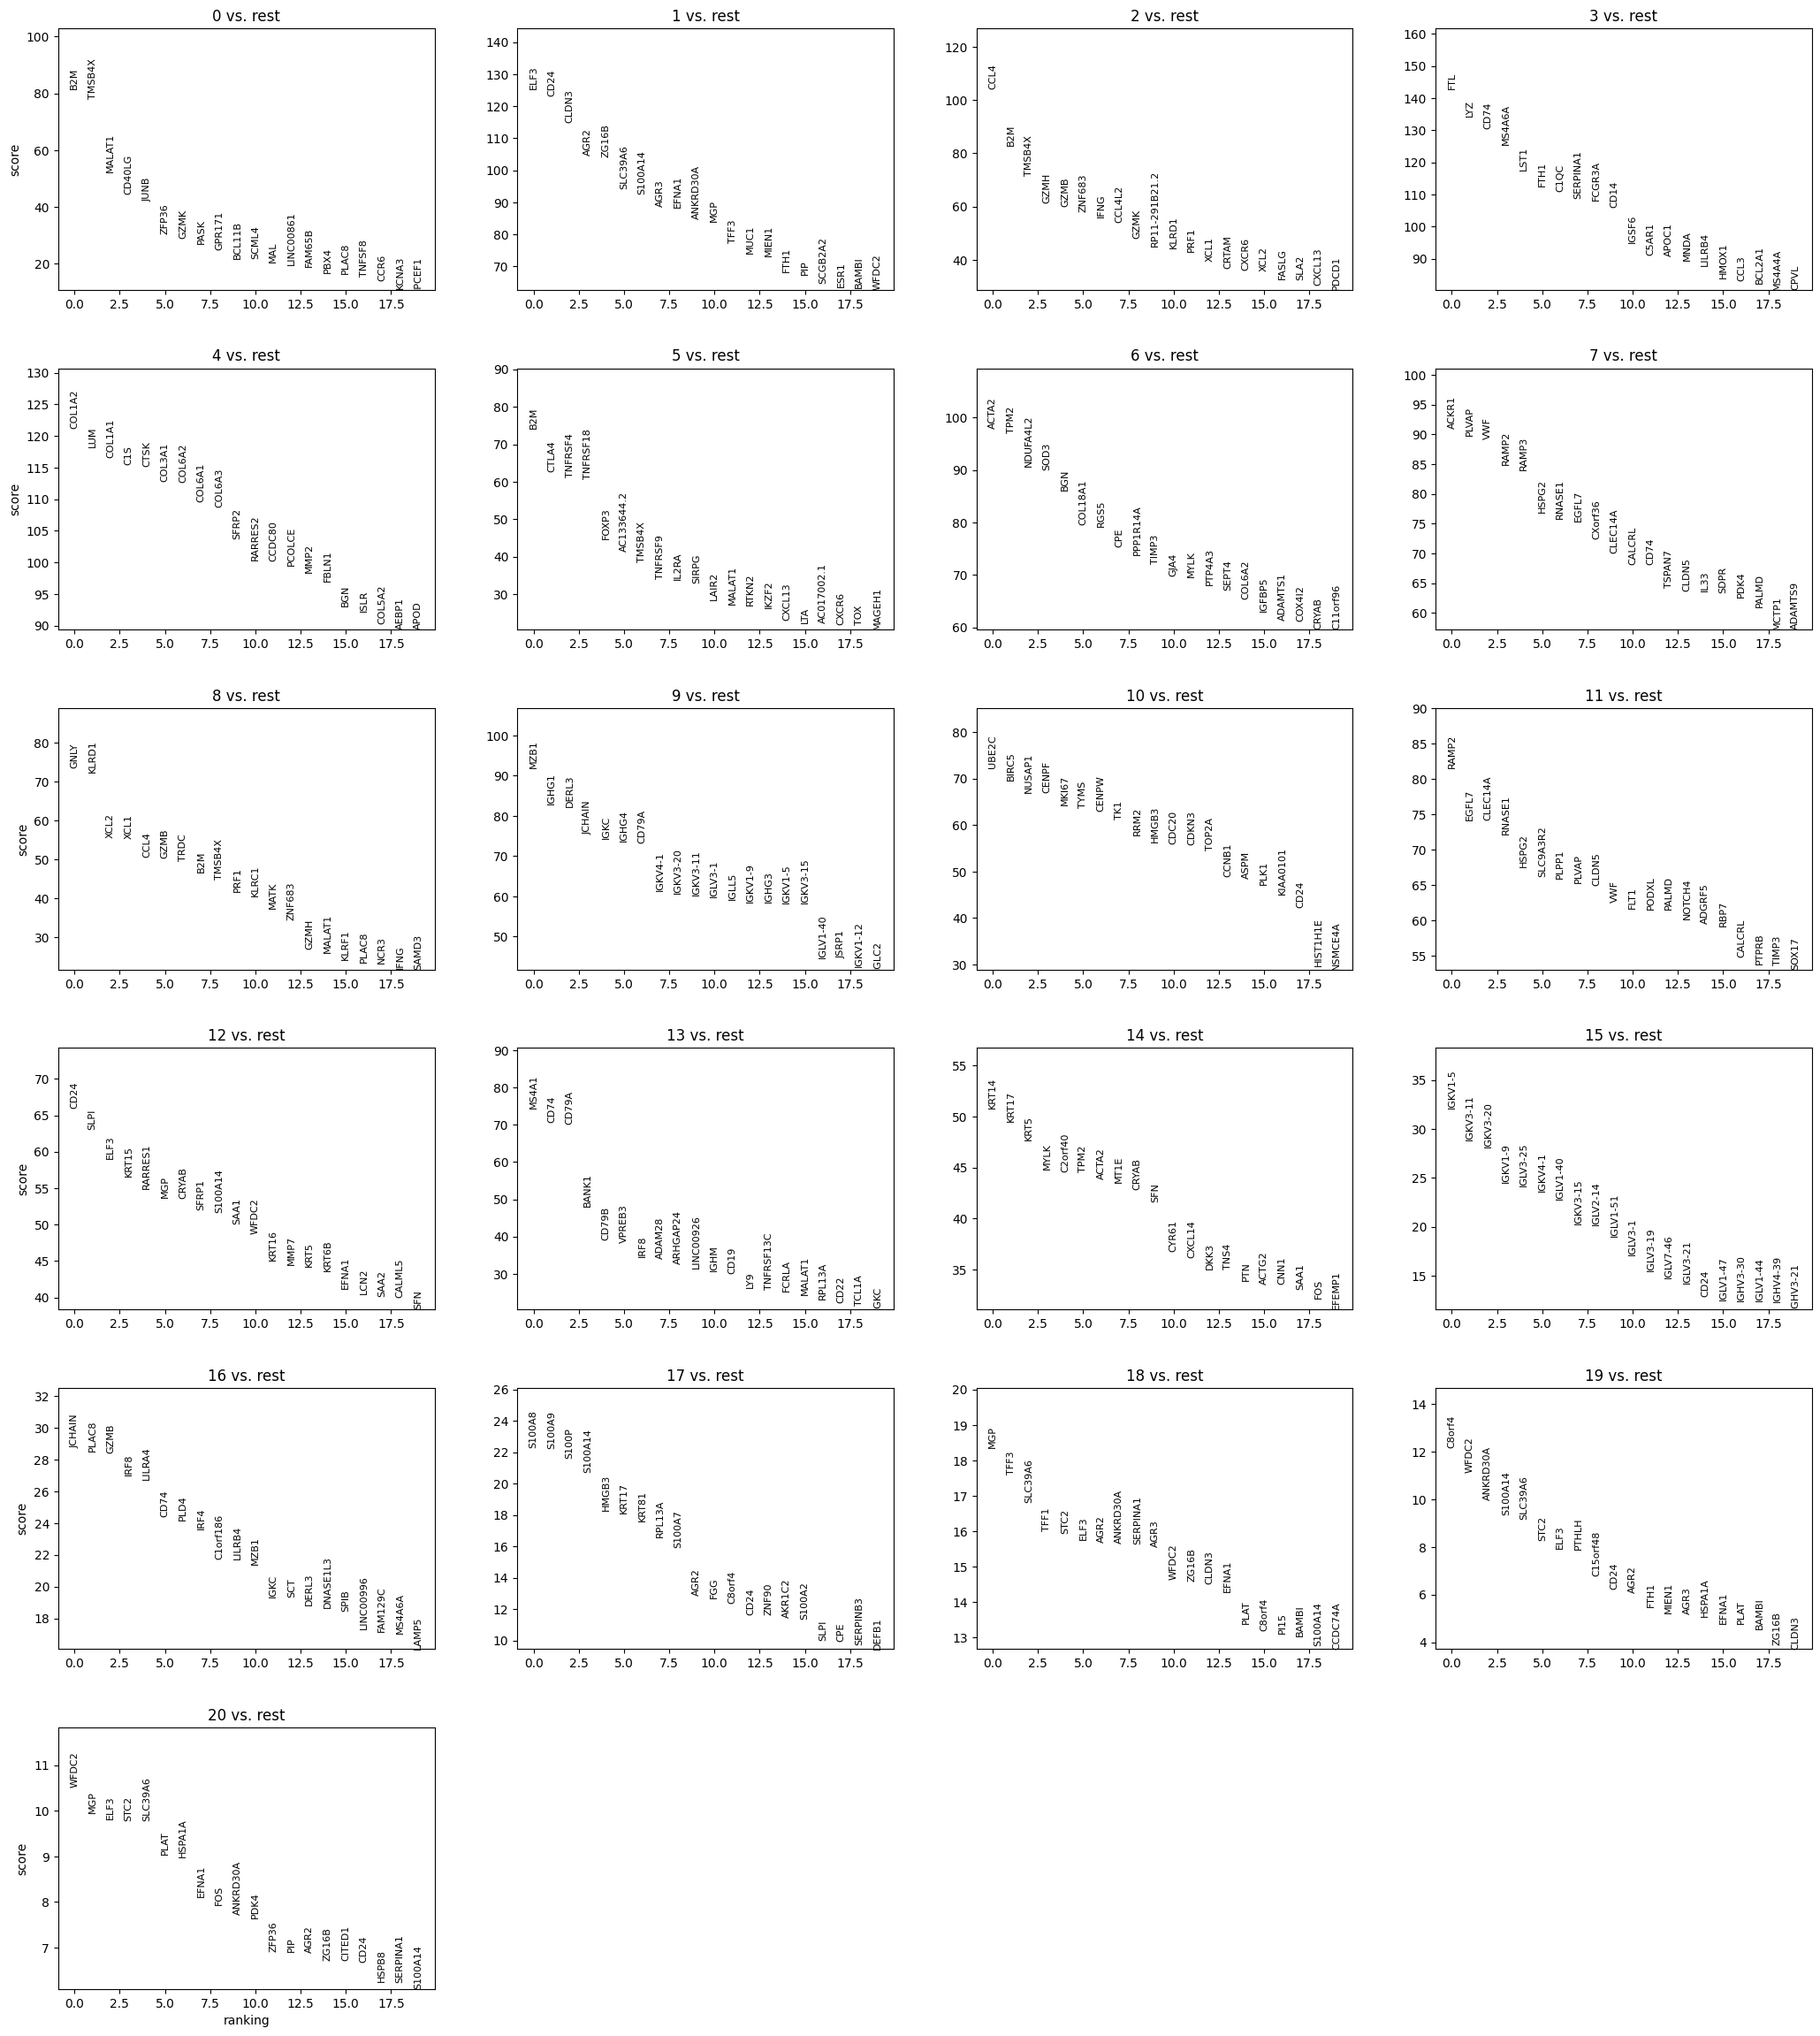

In [27]:
sc.pl.rank_genes_groups(
    adata1,
    n_genes=20,
    sharey=False
)

sc.pl.rank_genes_groups(
    adata2,
    n_genes=20,
    sharey=False
)

In [28]:
markers1 = sc.get.rank_genes_groups_df(adata1, None)
markers2 = sc.get.rank_genes_groups_df(adata2, None)

markers1.to_csv(
    RESULTS_DIR / "GSE114725_cluster_markers.csv",
    index=False
)

markers2.to_csv(
    RESULTS_DIR / "GSE176078_cluster_markers.csv",
    index=False
)

In [29]:
markers1_sorted = markers1.sort_values(
    ["group", "logfoldchanges"],
    ascending=[True, False]
)

markers2_sorted = markers2.sort_values(
    ["group", "logfoldchanges"],
    ascending=[True, False]
)

In [30]:
markers1_sorted.to_csv(
    RESULTS_DIR / "GSE114725_cluster_markers_sorted.csv",
    index=False
)

markers2_sorted.to_csv(
    RESULTS_DIR / "GSE176078_cluster_markers_sorted.csv",
    index=False
)

In [31]:
top10_markers1 = (
    markers1_sorted
    .groupby("group")
    .head(10)
)

top10_markers2 = (
    markers2_sorted
    .groupby("group")
    .head(10)
)

In [32]:
top10_markers1.to_csv(
    RESULTS_DIR / "GSE114725_top10_markers.csv",
    index=False
)

top10_markers2.to_csv(
    RESULTS_DIR / "GSE176078_top10_markers.csv",
    index=False
)

In [33]:
markers1.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,TPT1,100.811462,NaN,0.0,0.0
1,0,RPS12,96.503853,NaN,0.0,0.0
2,0,RPLP2,96.403870,NaN,0.0,0.0
3,0,RPL13,95.529388,NaN,0.0,0.0
4,0,RPS27,69.022133,NaN,0.0,0.0


In [34]:
adata1.obs["leiden"] = adata1.obs["leiden_0.6"]
adata2.obs["leiden"] = adata2.obs["leiden_0.6"]

In [36]:
marker_genes = [
    "CD3D", "CD3E", "TRAC",
    "MS4A1", "CD79A",
    "NKG7", "GNLY",
    "LYZ", "CD68",
    "EPCAM", "KRT8", "KRT18", "KRT19"
]

present1 = [g for g in marker_genes if g in adata1.var_names]
present2 = [g for g in marker_genes if g in adata2.var_names]

print("GSE114725 present markers:", present1)
print("GSE176078 present markers:", present2)

GSE114725 present markers: ['MS4A1', 'CD79A', 'NKG7', 'GNLY', 'LYZ', 'CD68', 'KRT8', 'KRT18']
GSE176078 present markers: ['MS4A1', 'CD79A', 'GNLY', 'LYZ']


In [37]:
for cluster in sorted(top10_markers1["group"].unique()):
    genes = top10_markers1[top10_markers1["group"] == cluster]["names"].tolist()

    print("\n" + "="*50)
    print(f"Cluster {cluster}")
    print("="*50)

    for gene in genes:
        print(gene)


Cluster 0
PRSS36
ST7L
RP1-34B20.21
SIGLEC5
LRG1
RBFA
GPATCH1
JMJD4
ACTR5
MKI67

Cluster 1
IL1RL1
HES6
PIGO
PDGFRB
PDGFD
RBM43
ADGRG3
MZB1
DNASE1
HDC

Cluster 10
EIF3J-AS1
PLXDC1
CEP290
RPS6KB1
HMGXB4
ZNF862
RBM19
D2HGDH
NT5C3B
DNASE1

Cluster 2
GSDMB
WNT10A
TBC1D31
ZNF574
ZNF14
C1ORF186
TNFSF14
KIR3DL1
PIDD1
ALMS1

Cluster 3
NAIF1
ANKRD26
B9D2
PHLDA2
PPP1R3B
LACTB2
CTCF
ABHD11
ACP6
SDPR

Cluster 4
WNT10A
CEP152
CCL22
SLC22A18
AP1S3
ZFAT
MYO1D
PPP1R3B
LDOC1
ALMS1

Cluster 5
SHMT1
SPINK2
TSPAN2
TPSAB1
WDR75
ICA1
AC104820.2
MYO1D
CYB5D2
DSC2

Cluster 6
FAM30A
CYB5D2
GMPPB
TMEM209
JMJD4
C5AR2
SLC25A29
OBSCN
FSCN1
EIF3J-AS1

Cluster 7
CDCA4
MLC1
THBS1
FCGBP
METTL4
MICA
BEX5
PTGDS
KDELC2
CDK5R1

Cluster 8
ANKZF1
CRACR2A
PPP2R2B
FOLR2
METRN
CHIC2
TREM1
CD160
PDP2
PHC2

Cluster 9
B3GALT4
HLA-DRB1
CHI3L2
CD40
ALDOC
B4GALT4
KIR2DL1
FAM104B
MED11
LHPP


In [38]:
for cluster in sorted(top10_markers2["group"].unique()):
    genes = top10_markers2[top10_markers2["group"] == cluster]["names"].tolist()

    print("\n" + "="*50)
    print(f"Cluster {cluster}")
    print("="*50)

    for gene in genes:
        print(gene)


Cluster 0
IGHV2-26
CST2
RP1-60O19.1
IGHGP
CCL26
DGCR6
MCEMP1
KLK11
TUBA3D
APOC2

Cluster 1
IGHD
KCNJ2
OTOA
ADAMTSL2
TRBV4-2
TRBV3-1
IL21
F2RL3
IGHV3-33
IGKV3D-20

Cluster 10
CCL23
AADACL2-AS1
IGLV2-14
TRBV19
RP6-91H8.3
GSTM5
IGHA1
TNFRSF13B
IGLV3-19
TNS4

Cluster 11
IGKV1-17
IGLV3-9
IGKV1-6
AKR1C2
KIR2DL4
CH17-224D4.2
DNAAF1
IGKV1-27
TRBV6-5
TRGV3

Cluster 12
TRAV12-3
IL1R2
ADH1B
IGKV3D-11
IGKV1-6
KIR2DL4
IGLV3-9
DLK1
TRBV6-5
TYMS

Cluster 13
CCL23
GAL
OR51E1
TDO2
MTRNR2L1
DNAAF1
PIGR
TRAV9-2
TWIST1
ADH1B

Cluster 14
KLRC3
SERHL2
CD19
LINC00926
CRISP3
IGLV7-46
FCRL6
CASQ2
IL1R2
CYTL1

Cluster 15
CYP4Z1
HLA-DQB2
CTH
KIAA0125
JSRP1
KRT81
LYVE1
SCGB1B2P
NCOA5
CASQ2

Cluster 16
ENPEP
DAB2
IGHA1
C6orf15
CRABP1
IGLL5
PHGR1
BTNL9
ABI3BP
AC069363.1

Cluster 17
ABCA6
KDR
ADM
C6orf15
AC016831.7
CDC20
GABRP
LINC01480
CLEC3B
FXYD7

Cluster 18
FAM65B
WFDC1
METRNL
NMB
TBX2
IRF8
HSPA1A
OGN
GZMK
STC1

Cluster 19
MATK
CCDC102B
TOP2A
CRTAM
CYR61
TNFRSF4
PRF1
RASL11A
SLA2
CDKN3

Cluster 2
OXTR
BCO2
IGHV

In [39]:
print(adata1.shape)
print(adata2.shape)

(36607, 2000)
(82931, 2000)


In [40]:
!pip install celltypist

In [41]:
import celltypist
from celltypist import models

# Download the breast cancer / immune relevant model
# Immune_All_High is the best general immune model
# We will also use Breast_MammaryGland for GSE176078 cross-reference
models.download_models(force_update=False)

???? Storing models in C:\Users\annam\.celltypist\data\models
??? Skipping [1/61]: Immune_All_Low.pkl (file exists)
??? Skipping [2/61]: Immune_All_High.pkl (file exists)
??? Skipping [3/61]: Adult_COVID19_PBMC.pkl (file exists)
??? Skipping [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
??? Skipping [5/61]: Adult_Human_MTG.pkl (file exists)
??? Skipping [6/61]: Adult_Human_PancreaticIslet.pkl (file exists)
??? Skipping [7/61]: Adult_Human_PrefrontalCortex.pkl (file exists)
??? Skipping [8/61]: Adult_Human_Skin.pkl (file exists)
??? Skipping [9/61]: Adult_Human_Vascular.pkl (file exists)
??? Skipping [10/61]: Adult_Mouse_Gut.pkl (file exists)
??? Skipping [11/61]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
??? Skipping [12/61]: Adult_Pig_Hippocampus.pkl (file exists)
??? Skipping [13/61]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
??? Skipping [14/61]: Adult_cHSPCs_Illumina.pkl (file exists)
??? Skipping [15/61]: Adult_cHSPCs_Ultima.pkl (file exists)
??? Skipping

In [42]:
import sys
print(sys.executable)

C:\Users\annam\anaconda3\envs\scrna\python.exe


In [43]:
import sys
!{sys.executable} -m pip install celltypist

In [44]:
models.get_all_models()

['Adult_cHSPCs_Illumina.pkl',
 'Adult_cHSPCs_Ultima.pkl',
 'Adult_COVID19_PBMC.pkl',
 'Adult_CynomolgusMacaque_Hippocampus.pkl',
 'Adult_Human_MTG.pkl',
 'Adult_Human_PancreaticIslet.pkl',
 'Adult_Human_PrefrontalCortex.pkl',
 'Adult_Human_Skin.pkl',
 'Adult_Human_Vascular.pkl',
 'Adult_Mouse_Gut.pkl',
 'Adult_Mouse_OlfactoryBulb.pkl',
 'Adult_Pig_Hippocampus.pkl',
 'Adult_RhesusMacaque_Hippocampus.pkl',
 'Autopsy_COVID19_Lung.pkl',
 'Cells_Adult_Breast.pkl',
 'Cells_Fetal_Lung.pkl',
 'Cells_Human_Tonsil.pkl',
 'Cells_Intestinal_Tract.pkl',
 'Cells_Lung_Airway.pkl',
 'COVID19_HumanChallenge_Blood.pkl',
 'COVID19_Immune_Landscape.pkl',
 'Developing_Human_Brain.pkl',
 'Developing_Human_Gonads.pkl',
 'Developing_Human_Hippocampus.pkl',
 'Developing_Human_Organs.pkl',
 'Developing_Human_Thymus.pkl',
 'Developing_Mouse_Brain.pkl',
 'Developing_Mouse_Hippocampus.pkl',
 'Fetal_Human_AdrenalGlands.pkl',
 'Fetal_Human_Pancreas.pkl',
 'Fetal_Human_Pituitary.pkl',
 'Fetal_Human_Retina.pkl',
 'Fet

In [45]:
# CellTypist expects log-normalised data in adata.X
# Our data is already log1p normalised so this is correct

predictions1 = celltypist.annotate(
    adata1,
    model="Immune_All_High.pkl",
    majority_voting=True  # smooths predictions using neighbours
)

# Transfer predictions back into adata
adata1 = predictions1.to_adata()

print(adata1.obs["majority_voting"].value_counts())

ValueError: ???? Invalid expression matrix in `.X`, expect log1p normalized expression to 10000 counts per cell

In [46]:
print(adata1.X.min())
print(adata1.X.max())

-4.330071165733016
10.0


In [47]:
PROCESSED_DIR_FULL = Path(r"C:\Users\annam\Dissertation 2026\Data\Processed")

# Load the full-gene QC objects (saved before scaling)
adata1_full = sc.read_h5ad(PROCESSED_DIR_FULL / "GSE114725_phase1_qc_fullgenes.h5ad")
adata2_full = sc.read_h5ad(PROCESSED_DIR_FULL / "GSE176078_phase1_qc_fullgenes.h5ad")

# These still need normalising ??? check if already done
print(adata1_full.X.max())
print(adata2_full.X.max())

1236.0
29831.0


In [48]:
sc.pp.normalize_total(adata1_full, target_sum=1e4)
sc.pp.log1p(adata1_full)

sc.pp.normalize_total(adata2_full, target_sum=1e4)
sc.pp.log1p(adata2_full)

In [49]:
# Copy the UMAP coordinates and leiden clusters from adata1/adata2
# so CellTypist results land in the same coordinate space

adata1_full.obsm["X_umap"] = adata1.obsm["X_umap"]
adata1_full.obs["leiden_0.6"] = adata1.obs["leiden_0.6"]

adata2_full.obsm["X_umap"] = adata2.obsm["X_umap"]
adata2_full.obs["leiden_0.6"] = adata2.obs["leiden_0.6"]

print("Transferred UMAP and cluster labels")

ValueError: Value passed for key 'X_umap' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (36607,) while it should have had (36613,).

In [50]:
# Find the shared cell barcodes
shared_cells1 = adata1.obs_names  # 36607 cells (post-doublet removal)
shared_cells2 = adata2.obs_names  # 82931 cells

# Subset full-gene objects to matching cells only
adata1_full = adata1_full[shared_cells1].copy()
adata2_full = adata2_full[shared_cells2].copy()

print(adata1_full.shape)  # should now be (36607, ...)
print(adata2_full.shape)  # should now be (82931, ...)

(36607, 14751)
(82931, 27221)


In [51]:
adata1_full.obsm["X_umap"] = adata1.obsm["X_umap"]
adata1_full.obs["leiden_0.6"] = adata1.obs["leiden_0.6"]

adata2_full.obsm["X_umap"] = adata2.obsm["X_umap"]
adata2_full.obs["leiden_0.6"] = adata2.obs["leiden_0.6"]

print("Transferred UMAP and cluster labels")

Transferred UMAP and cluster labels


In [52]:
# Check what cluster columns actually exist
print("adata1 obs columns:", adata1.obs.columns.tolist())
print("adata2 obs columns:", adata2.obs.columns.tolist())

adata1 obs columns: ['patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden']
adata2 obs columns: ['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden']


In [53]:
# Step 1 ??? re-run clustering on both objects
adata1 = run_phase2_clustering(adata1, "GSE114725")
adata2 = run_phase2_clustering(adata2, "GSE176078")

# Step 2 ??? confirm leiden columns are now there
print(adata1.obs.columns.tolist())
print(adata2.obs.columns.tolist())

Running Phase 2 clustering for GSE114725
GSE114725 leiden_0.2 9 clusters
GSE114725 leiden_0.4 10 clusters
GSE114725 leiden_0.6 11 clusters
GSE114725 leiden_0.8 14 clusters
GSE114725 leiden_1.0 19 clusters
Running Phase 2 clustering for GSE176078
GSE176078 leiden_0.2 13 clusters
GSE176078 leiden_0.4 17 clusters
GSE176078 leiden_0.6 21 clusters
GSE176078 leiden_0.8 23 clusters
GSE176078 leiden_1.0 27 clusters
['patient', 'tissue', 'replicate', 'cluster', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden']
['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden_0.2', 'leiden_0.4', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden']


In [55]:
sc.tl.umap(adata1, random_state=42)
sc.tl.umap(adata2, random_state=42)

In [56]:
adata1.write(
    PROCESSED_DIR / "GSE114725_phase2_clustered.h5ad",
    compression="gzip"
)
adata2.write(
    PROCESSED_DIR / "GSE176078_phase2_clustered.h5ad",
    compression="gzip"
)
print("Saved clustered objects")

Saved clustered objects


In [57]:
shared_cells1 = adata1.obs_names
shared_cells2 = adata2.obs_names

adata1_full = adata1_full[shared_cells1].copy()
adata2_full = adata2_full[shared_cells2].copy()

adata1_full.obsm["X_umap"] = adata1.obsm["X_umap"]
adata1_full.obs["leiden_0.6"] = adata1.obs["leiden_0.6"]

adata2_full.obsm["X_umap"] = adata2.obsm["X_umap"]
adata2_full.obs["leiden_0.6"] = adata2.obs["leiden_0.6"]

print("Done:", adata1_full.shape, adata2_full.shape)

Done: (36607, 14751) (82931, 27221)


In [58]:
predictions1 = celltypist.annotate(
    adata1_full,
    model="Immune_All_High.pkl",
    majority_voting=True
)
adata1_full = predictions1.to_adata()

predictions2 = celltypist.annotate(
    adata2_full,
    model="Immune_All_High.pkl",
    majority_voting=True
)
adata2_full = predictions2.to_adata()

print("GSE114725 cell types:")
print(adata1_full.obs["majority_voting"].value_counts())
print("\nGSE176078 cell types:")
print(adata2_full.obs["majority_voting"].value_counts())

???? Input data has 36607 cells and 14751 genes
???? Matching reference genes in the model
???? 4883 features used for prediction
?????? Scaling input data
??????? Predicting labels
??? Prediction done!
???? Can not detect a neighborhood graph, will construct one before the over-clustering
?????? Over-clustering input data with resolution set to 15
??????? Majority voting the predictions
??? Majority voting done!
???? Input data has 82931 cells and 27221 genes
???? Matching reference genes in the model
???? 5604 features used for prediction
?????? Scaling input data


MemoryError: Unable to allocate 3.46 GiB for an array with shape (82931, 5604) and data type float64

In [1]:
print(adata2_full)

NameError: name 'adata2_full' is not defined

In [10]:
def run_celltypist_batched(adata_full, model_name, batch_size=20000):
    n_cells = adata_full.n_obs
    all_predictions = []
    
    for start in range(0, n_cells, batch_size):
        end = min(start + batch_size, n_cells)
        print(f"Processing cells {start} to {end}...")
        
        batch = adata_full[start:end].copy()
        
        pred = celltypist.annotate(
            batch,
            model=model_name,
            majority_voting=False
        )
        all_predictions.append(pred.predicted_labels)
    
    combined = pd.concat(all_predictions)
    adata_full.obs["predicted_labels"] = combined["predicted_labels"].values
    
    print("Batched prediction done!")
    return adata_full

# GSE114725 first (already worked but redo for consistency)
predictions1 = celltypist.annotate(
    adata1_full,
    model="Immune_All_High.pkl",
    majority_voting=True
)
adata1_full = predictions1.to_adata()
print("GSE114725 done:")
print(adata1_full.obs["majority_voting"].value_counts())

# GSE176078 batched
adata2_full = run_celltypist_batched(
    adata2_full,
    "Immune_All_High.pkl",
    batch_size=20000
)
print("\nGSE176078 done:")
print(adata2_full.obs["predicted_labels"].value_counts())

🔬 Input data has 36607 cells and 14751 genes
🔗 Matching reference genes in the model
🧬 4883 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


GSE114725 done:
majority_voting
T cells        25161
Macrophages     3431
ILC             2890
B cells         2661
Monocytes       1202
DC               821
Mast cells       270
pDC              171
Name: count, dtype: int64
Processing cells 0 to 20000...


🔬 Input data has 20000 cells and 27221 genes
🔗 Matching reference genes in the model
🧬 5604 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Processing cells 20000 to 40000...


🔬 Input data has 20000 cells and 27221 genes
🔗 Matching reference genes in the model
🧬 5604 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


...

Processing cells 60000 to 80000...


🔬 Input data has 20000 cells and 27221 genes
🔗 Matching reference genes in the model
🧬 5604 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🔬 Input data has 2931 cells and 27221 genes
🔗 Matching reference genes in the model


Processing cells 80000 to 82931...


🧬 5604 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!


Batched prediction done!

GSE176078 done:
predicted_labels
T cells                       31669
Epithelial cells              14346
Macrophages                    8116
Endothelial cells              7414
Fibroblasts                    7049
ILC                            3977
B cells                        3499
Plasma cells                   3288
DC                             1565
Monocytes                       972
Double-positive thymocytes      590
pDC                             319
Mono-mac                         27
Cycling cells                    22
Double-negative thymocytes       21
Mast cells                       14
HSC/MPP                          12
MNP                              12
Myelocytes                       12
ETP                               3
ILC precursor                     1
DC precursor                      1
Megakaryocytes/platelets          1
Erythroid                         1
Name: count, dtype: int64


In [8]:
# Check current state
print("adata1_full max:", adata1_full.X.max())
print("adata2_full max:", adata2_full.X.max())

adata1_full max: 1236.0
adata2_full max: 29831.0


In [9]:
sc.pp.normalize_total(adata1_full, target_sum=1e4)
sc.pp.log1p(adata1_full)

sc.pp.normalize_total(adata2_full, target_sum=1e4)
sc.pp.log1p(adata2_full)

print("Normalised - adata1_full max:", adata1_full.X.max())
print("Normalised - adata2_full max:", adata2_full.X.max())

Normalised - adata1_full max: 8.125568228752648
Normalised - adata2_full max: 9.063545


In [11]:
# Save CellTypist results
adata1_full.obs[["majority_voting"]].to_csv(
    RESULTS_DIR / "GSE114725_celltypist_labels.csv"
)
adata2_full.obs[["predicted_labels"]].to_csv(
    RESULTS_DIR / "GSE176078_celltypist_labels.csv"
)

# Compare GSE176078 CellTypist vs published labels
crosstab = pd.crosstab(
    adata2_full.obs["celltype_major"],
    adata2_full.obs["predicted_labels"]
)
crosstab.to_csv(RESULTS_DIR / "GSE176078_celltypist_vs_published.csv")
print(crosstab)

predicted_labels   B cells  Cycling cells    DC  DC precursor  \
celltype_major                                                  
B-cells               2684              0     4             0   
CAFs                    71              0    19             0   
Cancer Epithelial      308              2    90             1   
Endothelial              8              0     2             0   
Myeloid                 30              0  1254             0   
Normal Epithelial       33              0     1             0   
PVL                    307              0   187             0   
Plasmablasts             1              0     0             0   
T-cells                 57             20     8             0   

predicted_labels   Double-negative thymocytes  Double-positive thymocytes  \
celltype_major                                                              
B-cells                                     0                           0   
CAFs                                       19        

In [12]:
# Transfer CellTypist labels into clustered objects for plotting
adata2.obs["celltypist"] = adata2_full.obs["predicted_labels"].values
adata1.obs["celltypist"] = adata1_full.obs["majority_voting"].values

# Plot UMAPs
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sc.pl.umap(
    adata1,
    color="celltypist",
    title="GSE114725 — CellTypist",
    legend_loc="on data",
    legend_fontsize=6,
    ax=axes[0],
    show=False
)

sc.pl.umap(
    adata2,
    color="celltypist",
    title="GSE176078 — CellTypist",
    legend_loc="on data",
    legend_fontsize=6,
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "celltypist_umap_both.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()
print("Saved")

... storing 'celltypist' as categorical


Saved


In [13]:
fig_path = FIGURE_DIR / "celltypist_umap_both.png"
print("File exists:", fig_path.exists())
print("Full path:", fig_path.resolve())

File exists: True
Full path: C:\Users\annam\Dissertation 2026\figures\phase2_clustering\celltypist_umap_both.png


In [14]:
adata1.write(
    PROCESSED_DIR / "GSE114725_phase2_annotated.h5ad",
    compression="gzip"
)
adata2.write(
    PROCESSED_DIR / "GSE176078_phase2_annotated.h5ad",
    compression="gzip"
)
print("Saved annotated objects")

Saved annotated objects


In [15]:
# Define V(D)J prefixes to exclude
vdj_prefixes = ("IGHV", "IGLV", "IGKV", "TRAV", "TRBV", "TRGV", "TRDV")

# Get full marker table for GSE176078
sc.tl.rank_genes_groups(
    adata2,
    groupby="leiden_0.6",
    method="wilcoxon",
    key_added="rank_genes_leiden_0.6"
)

markers2_full = sc.get.rank_genes_groups_df(
    adata2,
    group=None,
    key="rank_genes_leiden_0.6"
)

# Filter out V(D)J genes
clean_markers2 = markers2_full[
    ~markers2_full["names"].str.startswith(vdj_prefixes)
]

# Top 10 per cluster
top10_clean = (
    clean_markers2
    .groupby("group")
    .head(10)
    .reset_index(drop=True)
)

# Print
for cluster in sorted(top10_clean["group"].unique(), key=lambda x: int(x)):
    genes = top10_clean[top10_clean["group"] == cluster]["names"].tolist()
    print(f"\n{'='*50}\nCluster {cluster}\n{'='*50}")
    for gene in genes:
        print(gene)

# Save
top10_clean.to_csv(
    RESULTS_DIR / "GSE176078_markers_no_vdj.csv",
    index=False
)
print("\nSaved clean marker table")

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is high


Cluster 0
B2M
TMSB4X
MALAT1
CD40LG
JUNB
ZFP36
GZMK
PASK
GPR171
BCL11B

Cluster 1
ELF3
CD24
CLDN3
AGR2
ZG16B
SLC39A6
S100A14
AGR3
EFNA1
ANKRD30A

Cluster 2
CCL4
B2M
TMSB4X
GZMH
GZMB
ZNF683
IFNG
CCL4L2
GZMK
RP11-291B21.2

Cluster 3
FTL
LYZ
CD74
MS4A6A
LST1
FTH1
C1QC
SERPINA1
FCGR3A
CD14

Cluster 4
COL1A2
LUM
COL1A1
C1S
CTSK
COL3A1
COL6A2
COL6A1
COL6A3
SFRP2

Cluster 5
B2M
CTLA4
TNFRSF4
TNFRSF18
FOXP3
AC133644.2
TMSB4X
TNFRSF9
IL2RA
SIRPG

Cluster 6
ACTA2
TPM2
NDUFA4L2
SOD3
BGN
COL18A1
RGS5
CPE
PPP1R14A
TIMP3

Cluster 7
ACKR1
PLVAP
VWF
RAMP2
RAMP3
HSPG2
RNASE1
EGFL7
CXorf36
CLEC14A

Cluster 8
GNLY
KLRD1
XCL2
XCL1
CCL4
GZMB
TRDC
B2M
TMSB4X
PRF1

Cluster 9
MZB1
IGHG1
DERL3
JCHAIN
IGKC
IGHG4
CD79A
IGLL5
IGHG3
JSRP1

Cluster 10
UBE2C
BIRC5
NUSAP1
CENPF
MKI67
TYMS
CENPW
TK1
RRM2
HMGB3

Cluster 11
RAMP2
EGFL7
CLEC14A
RNASE1
HSPG2
SLC9A3R2
PLPP1
PLVAP
CLDN5
VWF

Cluster 12
CD24
SLPI
ELF3
KRT15
RARRES1
MGP
CRYAB
SFRP1
S100A14
SAA1

Cluster 13
MS4A1
CD74
CD79A
BANK1
CD79B
VPREB3
IRF8
ADAM28
ARHGA

In [16]:
sc.tl.rank_genes_groups(
    adata1,
    groupby="leiden_0.6",
    method="wilcoxon",
    key_added="rank_genes_leiden_0.6"
)

markers1_full = sc.get.rank_genes_groups_df(
    adata1,
    group=None,
    key="rank_genes_leiden_0.6"
)

clean_markers1 = markers1_full[
    ~markers1_full["names"].str.startswith(vdj_prefixes)
]

top10_clean1 = (
    clean_markers1
    .groupby("group")
    .head(10)
    .reset_index(drop=True)
)

for cluster in sorted(top10_clean1["group"].unique(), key=lambda x: int(x)):
    genes = top10_clean1[top10_clean1["group"] == cluster]["names"].tolist()
    print(f"\n{'='*50}\nCluster {cluster}\n{'='*50}")
    for gene in genes:
        print(gene)

top10_clean1.to_csv(
    RESULTS_DIR / "GSE114725_markers_no_vdj.csv",
    index=False
)
print("\nSaved")


Cluster 0
TPT1
RPS12
RPLP2
RPL13
RPS27
CCR7
STMN3
RNF157
FAM134B
SUSD3

Cluster 1
BTG1
CXCR4
RPS27
ZFP36L2
TSC22D3
JUNB
TPT1
DUSP1
RPS12
KLRB1

Cluster 2
CST3
FTL
HLA-DRA
FTH1
CD74
TYROBP
LYZ
HLA-DRB1
GRN
HLA-DPA1

Cluster 3
CCL5
CD8A
CCL4
CXCR4
BTG1
ZFP36L2
DUSP2
ZFP36
GZMK
CD8B

Cluster 4
GNLY
NKG7
PRF1
CST7
KLRD1
FGFBP2
CCL5
GZMB
CTSW
IL2RB

Cluster 5
CD74
CD79A
HLA-DRA
IGHM
IGKC
HLA-DPB1
HLA-DPA1
HLA-DQB1
MS4A1
CD79B

Cluster 6
FOXP3
TIGIT
CTLA4
IL2RA
TNFRSF4
DUSP4
RTKN2
BATF
TNFRSF18
IKZF2

Cluster 7
NEAT1
FTH1
IFITM2
S100A9
FPR1
FCGR3B
DUSP1
SLC25A37
SRGN
RGS2

Cluster 8
TPSB2
CPA3
TPSAB1
MS4A2
KIT
GATA2
VWA5A
SLC18A2
EGR1
FOSB

Cluster 9
MGP
COL1A1
DCN
IGFBP7
CEBPD
APOD
COL1A2
TIMP3
IFITM3
LMNA

Cluster 10
JCHAIN
GZMB
IRF8
IRF7
TCF4
CD74
LILRA4
IGKC
CST3
GRN

Saved


In [17]:
# Resolution comparison UMAPs for GSE114725
fig, axes = plt.subplots(1, 5, figsize=(30, 5))
for i, res in enumerate(["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"]):
    sc.pl.umap(adata1, color=res, title=f"GSE114725 {res}", 
               legend_loc="on data", legend_fontsize=6, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE114725_resolution_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

# Resolution comparison UMAPs for GSE176078
fig, axes = plt.subplots(1, 5, figsize=(30, 5))
for i, res in enumerate(["leiden_0.2", "leiden_0.4", "leiden_0.6", "leiden_0.8", "leiden_1.0"]):
    sc.pl.umap(adata2, color=res, title=f"GSE176078 {res}",
               legend_loc="on data", legend_fontsize=6, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_resolution_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved resolution comparison figures")

Saved resolution comparison figures
